# Outlier Analysis Visualization
Load `outlier_results.h5` produced by notebook 3 and plot grid-point statistics
as a function of `amp_prefactor` and `charge_gate`.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5

## 1. Configuration

In [12]:
ROOT_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04\three_step"

OUTLIER_RESULTS_PATH = os.path.join(ROOT_FOLDER, "outlier_results.h5")
POST_SELECTED_PATH = os.path.join(ROOT_FOLDER, "ro_charge_power_post_selected.h5")

FIGURE_SAVE_PATH = os.path.join(ROOT_FOLDER, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

AMP_PREFACTOR_MAX_N = 1.10  # All amp_prefactor values are multiplied by this factor

## 2. Load Dataset

In [13]:
result_ds = load_xarray_h5(OUTLIER_RESULTS_PATH)
result_ds = result_ds.assign_coords(
    amp_prefactor=result_ds.coords['amp_prefactor'] * AMP_PREFACTOR_MAX_N
)
result_ds

<xarray.Dataset> Size: 126kB
Dimensions:                   (prepared_state: 2, amp_prefactor: 20,
                               charge_gate: 49)
Coordinates:
  * prepared_state            (prepared_state) int32 8B 0 1
  * charge_gate               (charge_gate) float64 392B 0.0 0.01 ... 0.47 0.48
  * amp_prefactor             (amp_prefactor) float64 160B 0.0 0.11 ... 2.09
Data variables:
    outlier_probability_set3  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    std_set3                  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    outlier_probability_set2  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set2               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set2               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    std_set2                  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
Attributes:
    mean:           [-0.00212459 -0.00141652]
    std:            0.0005476706919487206
    outlier_sigma:  3

## 3. Plot Grid-Point Statistics
For each prepared state, plot side-by-side comparisons of set_2 (left) vs set_3 (right).

Saved std_state_0.png


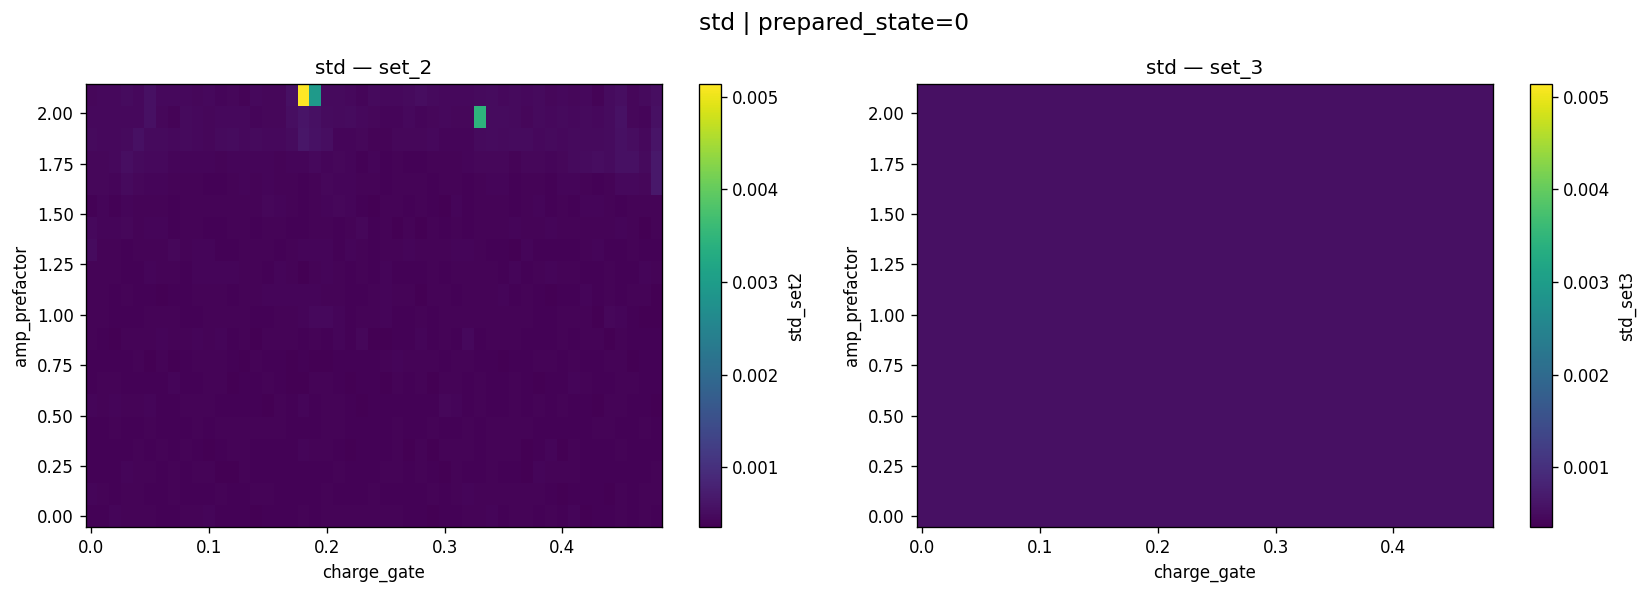

Saved I_mean_state_0.png


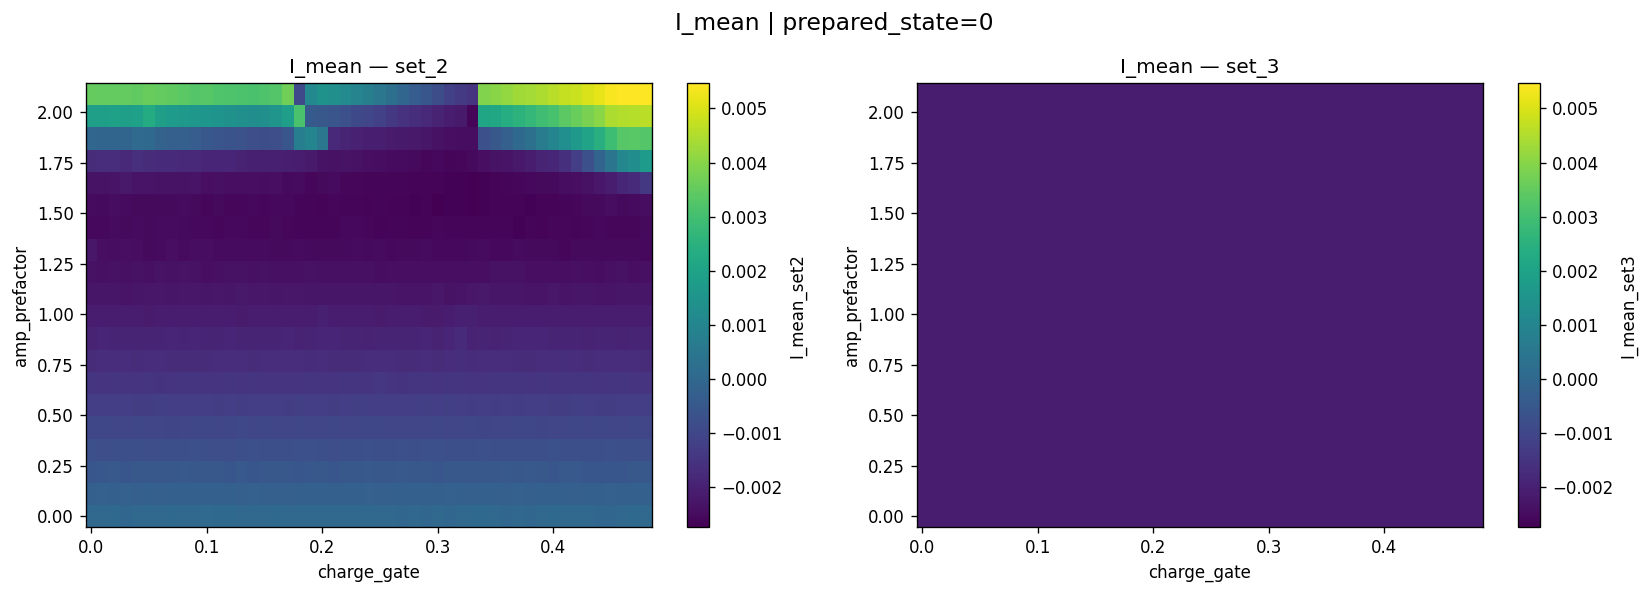

Saved Q_mean_state_0.png


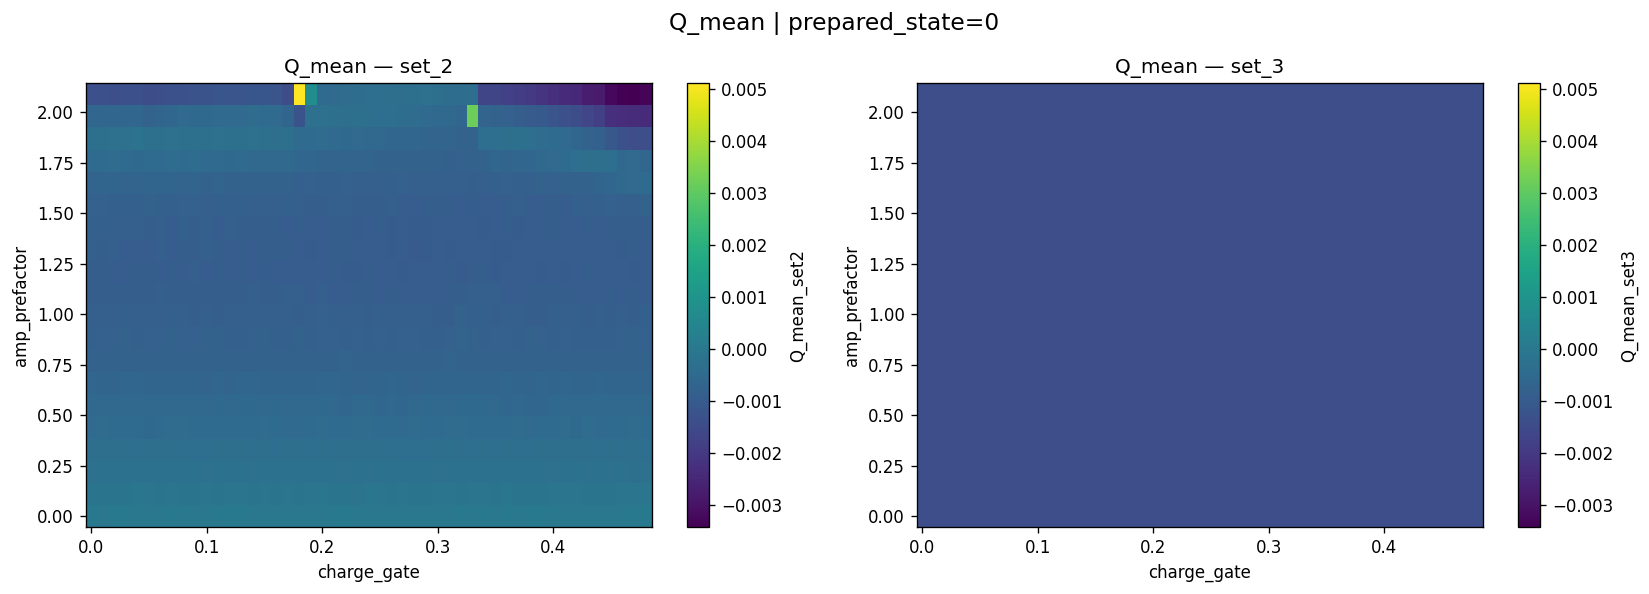

Saved outlier_probability_state_0.png


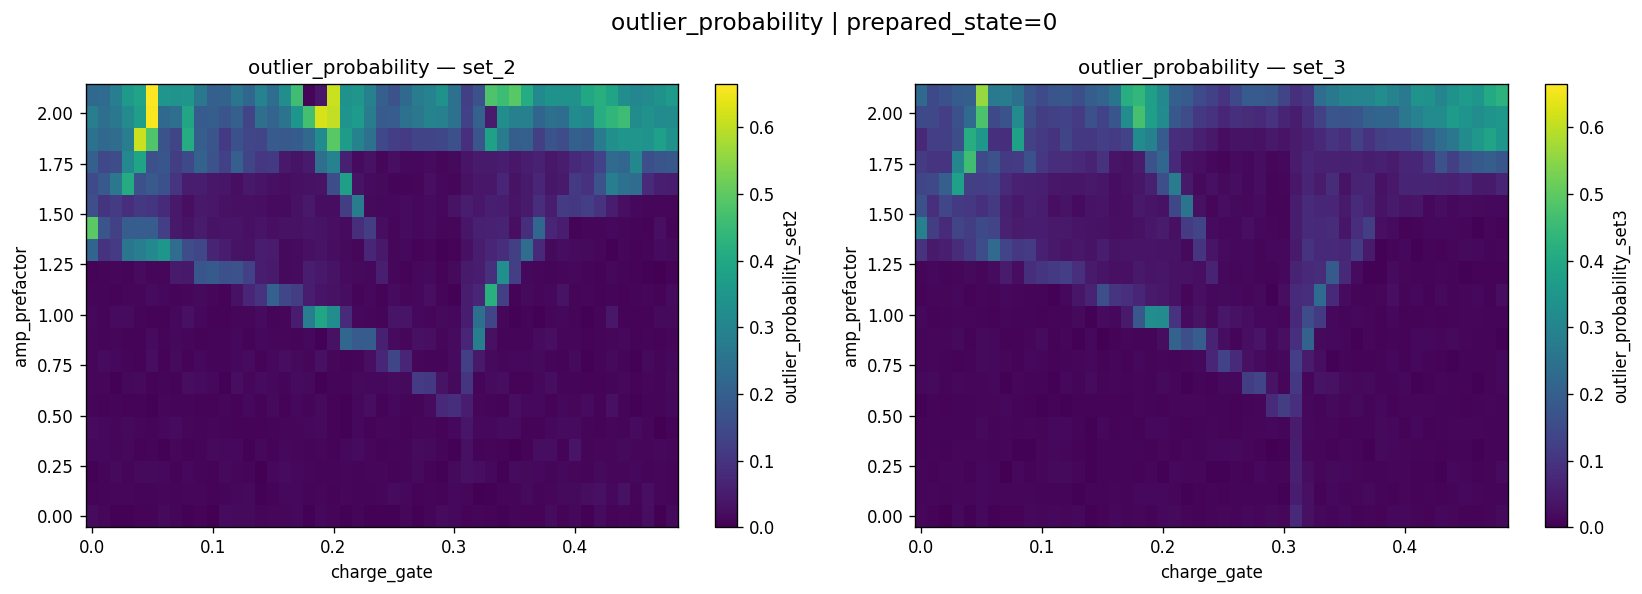

Saved std_state_1.png


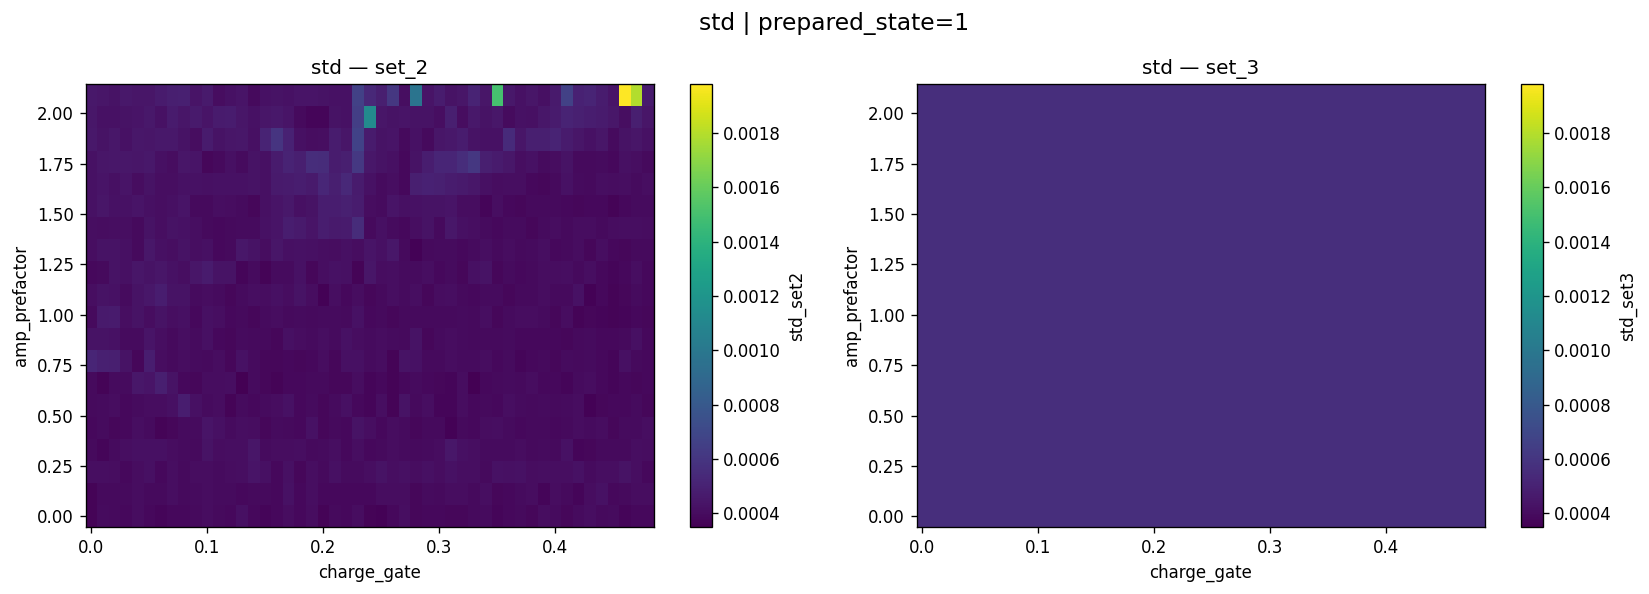

Saved I_mean_state_1.png


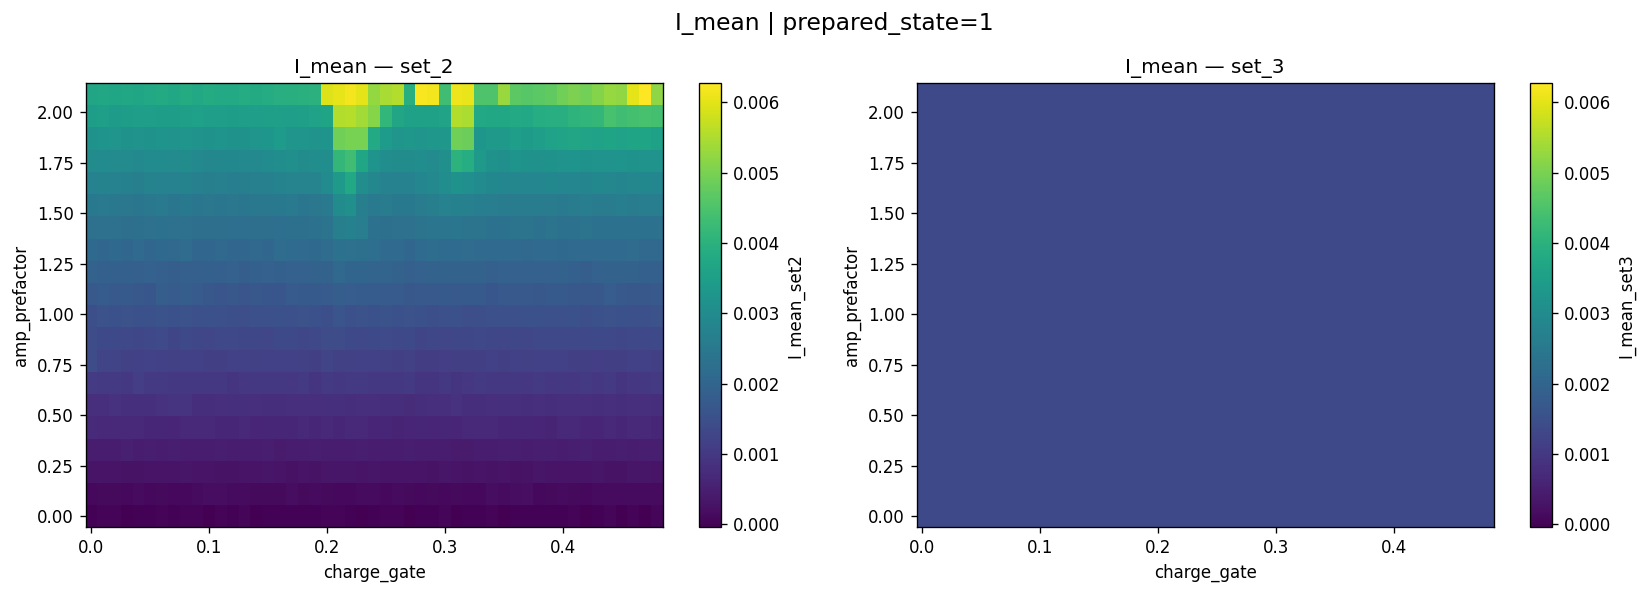

Saved Q_mean_state_1.png


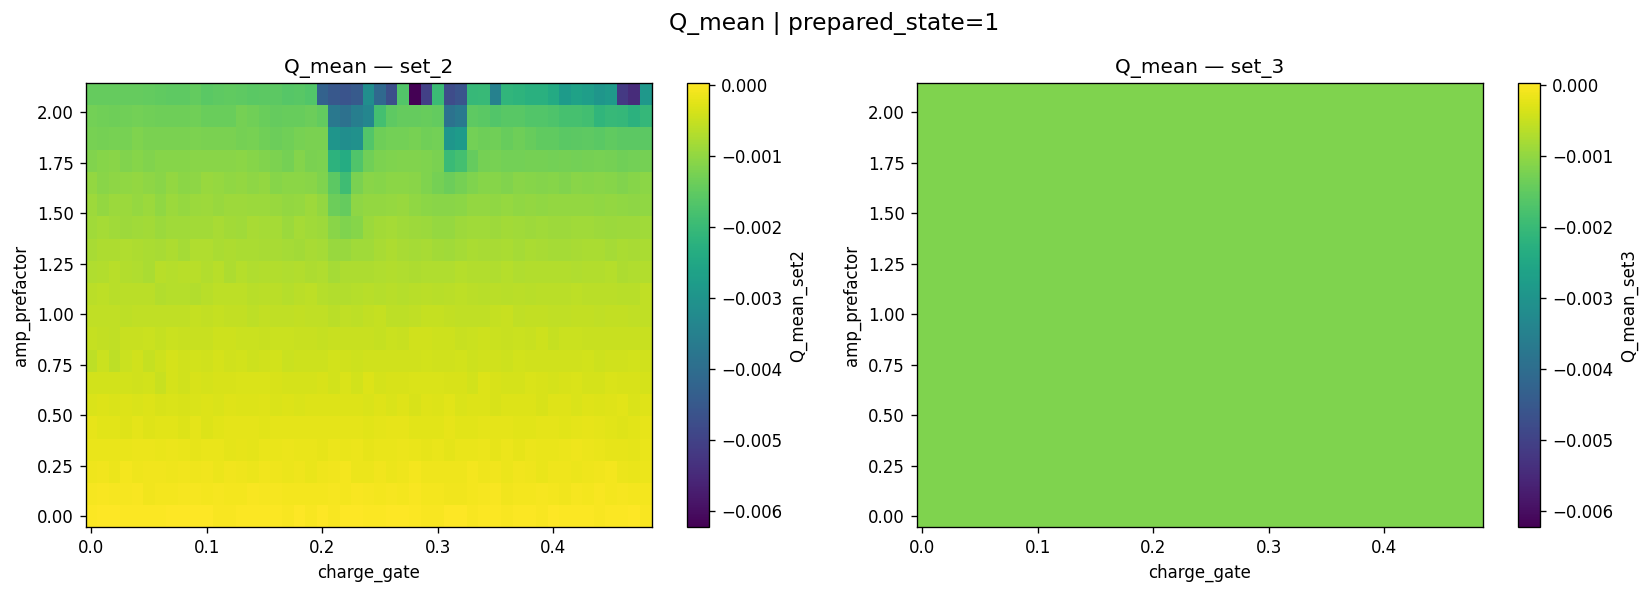

Saved outlier_probability_state_1.png


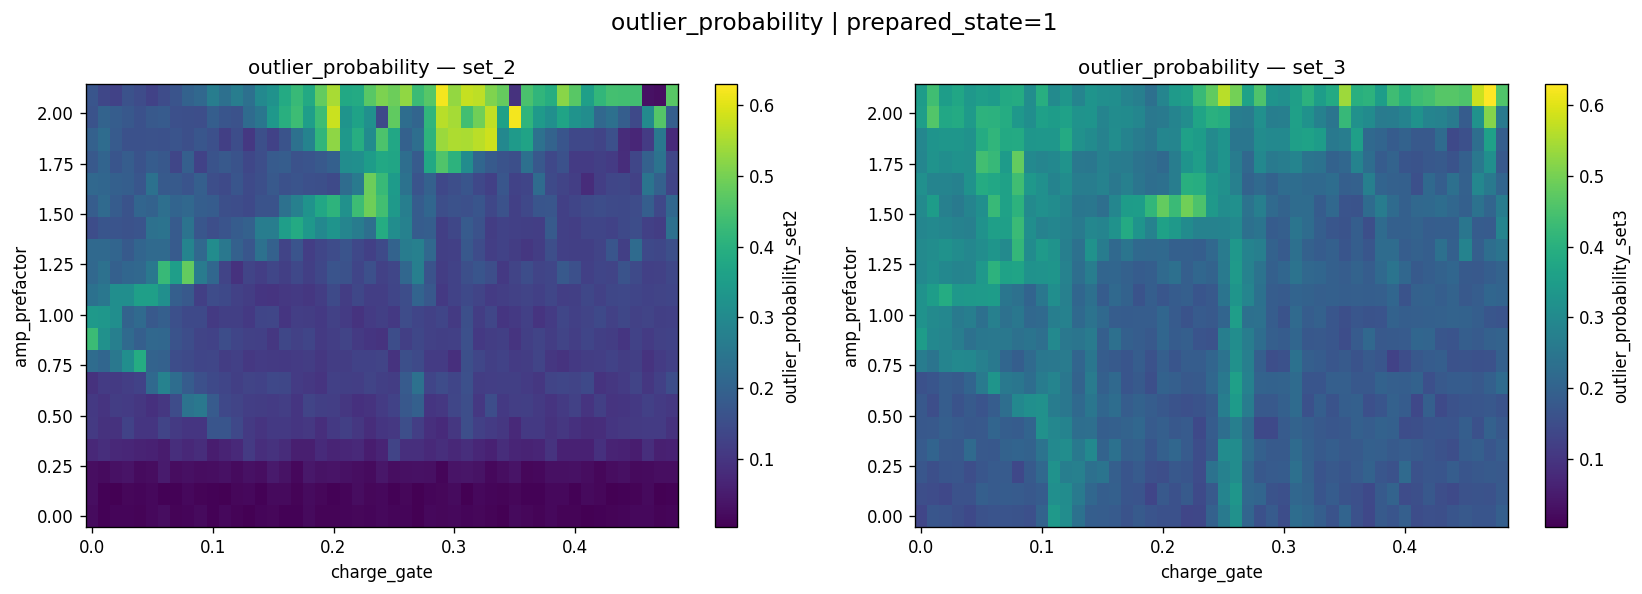

In [14]:
# Variable pairs to plot: (set2_var, set3_var, display_label)
var_pairs = [
    ('std_set2',                 'std_set3',                 'std'),
    ('I_mean_set2',              'I_mean_set3',              'I_mean'),
    ('Q_mean_set2',              'Q_mean_set3',              'Q_mean'),
    ('outlier_probability_set2', 'outlier_probability_set3', 'outlier_probability'),
]

prepared_states = result_ds.coords['prepared_state'].values

for state in prepared_states:
    for var2, var3, label in var_pairs:
        da2 = result_ds[var2].sel(prepared_state=state)
        da3 = result_ds[var3].sel(prepared_state=state)

        # Shared color range across set_2 and set_3
        import numpy as np
        vmin = float(np.nanmin([da2.min(), da3.min()]))
        vmax = float(np.nanmax([da2.max(), da3.max()]))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

        da2.plot.pcolormesh(
            ax=axes[0], x='charge_gate', y='amp_prefactor',
            cmap='viridis', add_colorbar=True, vmin=vmin, vmax=vmax,
        )
        axes[0].set_title(f"{label} — set_2")

        da3.plot.pcolormesh(
            ax=axes[1], x='charge_gate', y='amp_prefactor',
            cmap='viridis', add_colorbar=True, vmin=vmin, vmax=vmax,
        )
        axes[1].set_title(f"{label} — set_3")

        fig.suptitle(f"{label} | prepared_state={int(state)}", fontsize=14)
        fig.tight_layout()

        fname = f"{label}_state_{int(state)}.png"
        fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
        print(f"Saved {fname}")
        plt.show()

Saved delta_I_set2.png


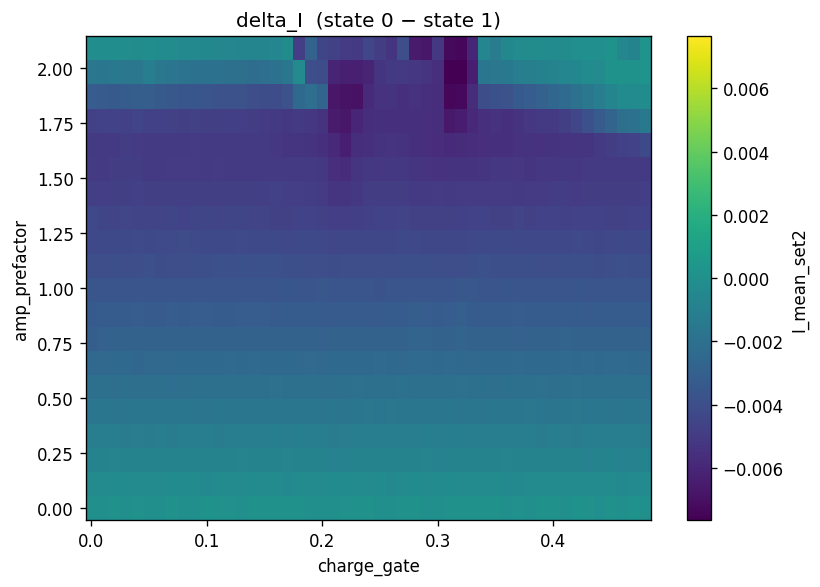

Saved delta_Q_set2.png


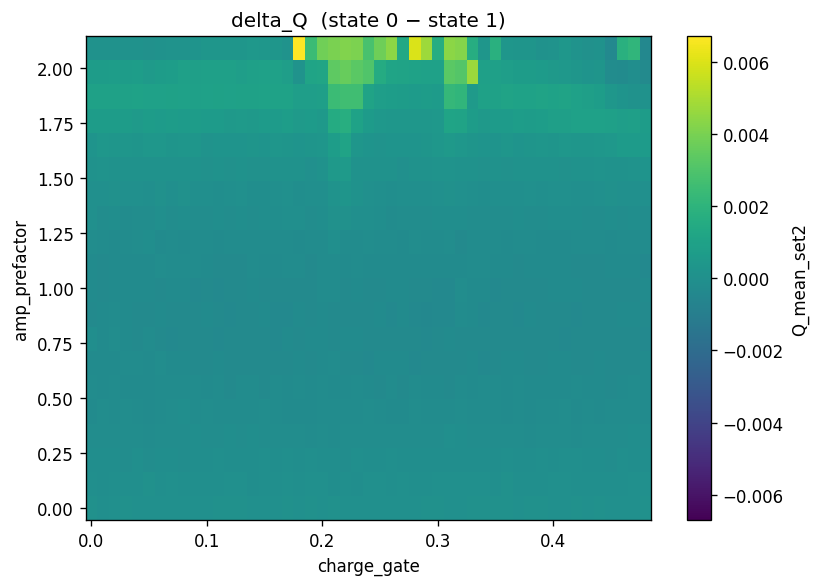

In [15]:
# Delta I, Delta Q, and IQ distance between prepared_state=0 and prepared_state=1
import numpy as np

delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
           - result_ds['I_mean_set2'].sel(prepared_state=1))
delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
           - result_ds['Q_mean_set2'].sel(prepared_state=1))
distance = np.sqrt(delta_I**2 + delta_Q**2)

for data, label in [(delta_I, 'delta_I'), (delta_Q, 'delta_Q')]:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
    data.plot.pcolormesh(
        ax=ax, x='charge_gate', y='amp_prefactor',
        cmap='viridis', add_colorbar=True,
    )
    ax.set_title(f"{label}  (state 0 − state 1)")
    fig.tight_layout()

    fname = f"{label}_set2.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved IQ_distance_set2.png


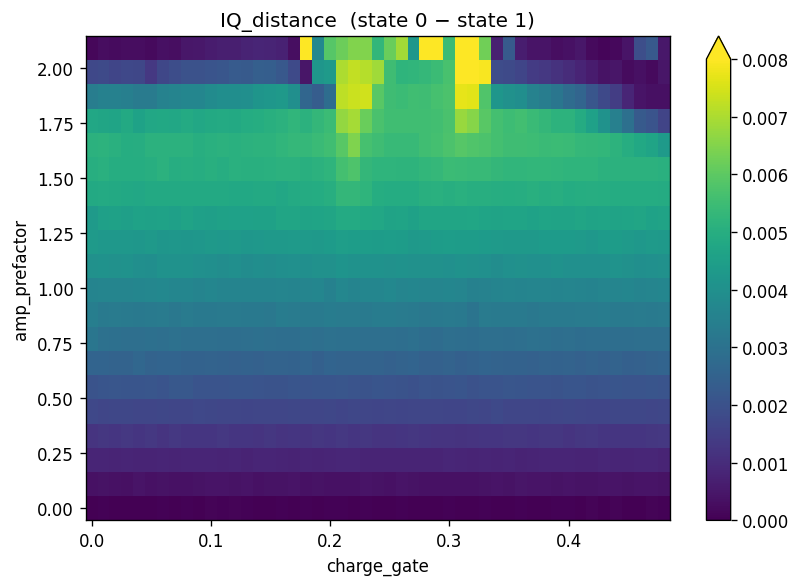

In [16]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
distance.plot.pcolormesh(
    ax=ax, x='charge_gate', y='amp_prefactor',
    cmap='viridis', add_colorbar=True, vmin=0, vmax=0.008,
)
ax.set_title("IQ_distance  (state 0 − state 1)")
fig.tight_layout()

fname = "IQ_distance_set2.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved IQ_distance_normalized_set2.png


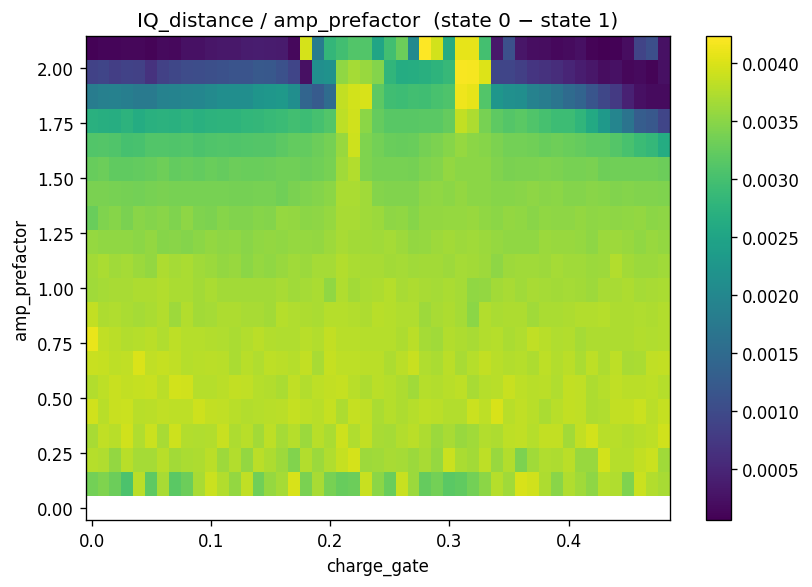

In [17]:
# Normalized distance: distance / amp_prefactor (excluding amp_prefactor == 0)
amp = distance.coords['amp_prefactor']
norm_distance = distance.where(amp != 0) / amp.where(amp != 0)

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
norm_distance.plot.pcolormesh(
    ax=ax, x='charge_gate', y='amp_prefactor',
    cmap='viridis', add_colorbar=True,
)
ax.set_title("IQ_distance / amp_prefactor  (state 0 − state 1)")
fig.tight_layout()

fname = "IQ_distance_normalized_set2.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved mean_IQ_distance_vs_amp.png


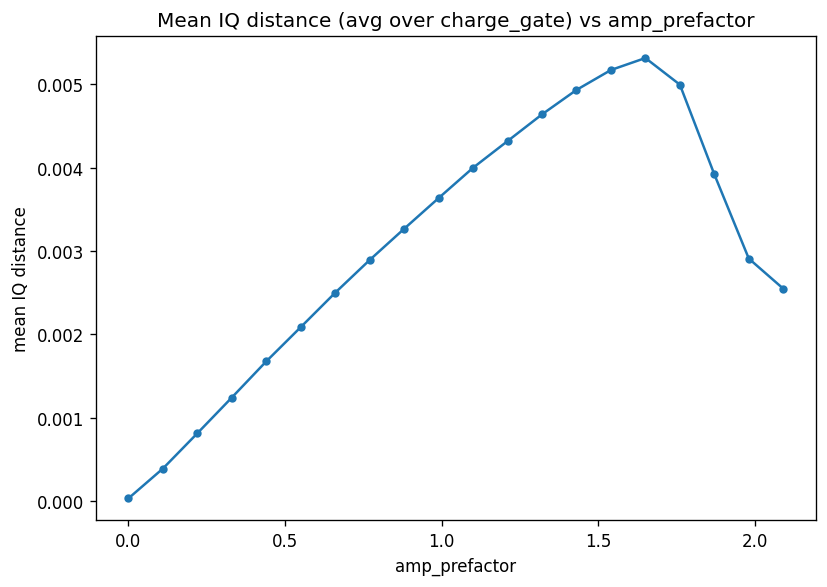

In [18]:
# Mean distance averaged along charge_gate vs amp_prefactor
mean_dist_vs_amp = distance.mean(dim='charge_gate')

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
mean_dist_vs_amp.plot.line(ax=ax, marker='o', markersize=4)
ax.set_xlabel('amp_prefactor')
ax.set_ylabel('mean IQ distance')
ax.set_title('Mean IQ distance (avg over charge_gate) vs amp_prefactor')
fig.tight_layout()

fname = "mean_IQ_distance_vs_amp.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

## 4. Single Grid-Point I/Q Scatter
Load `ro_charge_power_post_selected.h5` and plot per-shot I vs Q scatter at a user-chosen grid point,
with outliers highlighted.

In [22]:
import numpy as np

# --- User settings ---
SELECTED_STATE = 1       # prepared_state value
SELECTED_AMP   = 0.9     # amp_prefactor value (nearest match, before scaling)
SELECTED_CG    = 0.09    # charge_gate value   (nearest match)

ps_data = load_xarray_h5(POST_SELECTED_PATH)
ps_data = ps_data.assign_coords(
    amp_prefactor=ps_data.coords['amp_prefactor'] * AMP_PREFACTOR_MAX_N
)

# Select nearest grid point
cell = ps_data.sel(
    prepared_state=SELECTED_STATE,
    amp_prefactor=SELECTED_AMP * AMP_PREFACTOR_MAX_N,
    charge_gate=SELECTED_CG,
    method='nearest',
)
actual_state = float(cell.coords['prepared_state'])
actual_amp   = float(cell.coords['amp_prefactor'])
actual_cg    = float(cell.coords['charge_gate'])
print(f"Selected grid point: prepared_state={actual_state}, "
      f"amp_prefactor={actual_amp}, charge_gate={actual_cg}")
cell

Selected grid point: prepared_state=1.0, amp_prefactor=0.99, charge_gate=0.09


<xarray.Dataset> Size: 59kB
Dimensions:         (shot_idx: 1040)
Coordinates:
    charge_gate     float64 8B 0.09
    prepared_state  int32 4B 1
    qubit           object 8B 'q1'
  * shot_idx        (shot_idx) int64 8kB 0 1 2 3 4 ... 1035 1036 1037 1038 1039
    amp_prefactor   float64 8B 0.99
Data variables:
    I1_1            (shot_idx) float64 8kB -0.002463 -0.002269 ... -0.00242
    I1_2            (shot_idx) float64 8kB -0.002354 0.0008515 ... 0.00178
    I1_3            (shot_idx) float64 8kB -0.002392 0.001746 ... 0.002091
    Q1_1            (shot_idx) float64 8kB -0.001535 -0.001045 ... -0.001638
    Q1_2            (shot_idx) float64 8kB -4.596e-05 -0.00086 ... -0.0009709
    Q1_3            (shot_idx) float64 8kB -0.001572 -0.002 ... -0.001298
    outlier_mask    (shot_idx) bool 1kB False False False ... False False False
Attributes:
    mean:     [-0.00213373 -0.0014113 ]
    std:      0.0005486714845222007

Saved scatter_IQ_state1_amp0.99_cg0.09.png


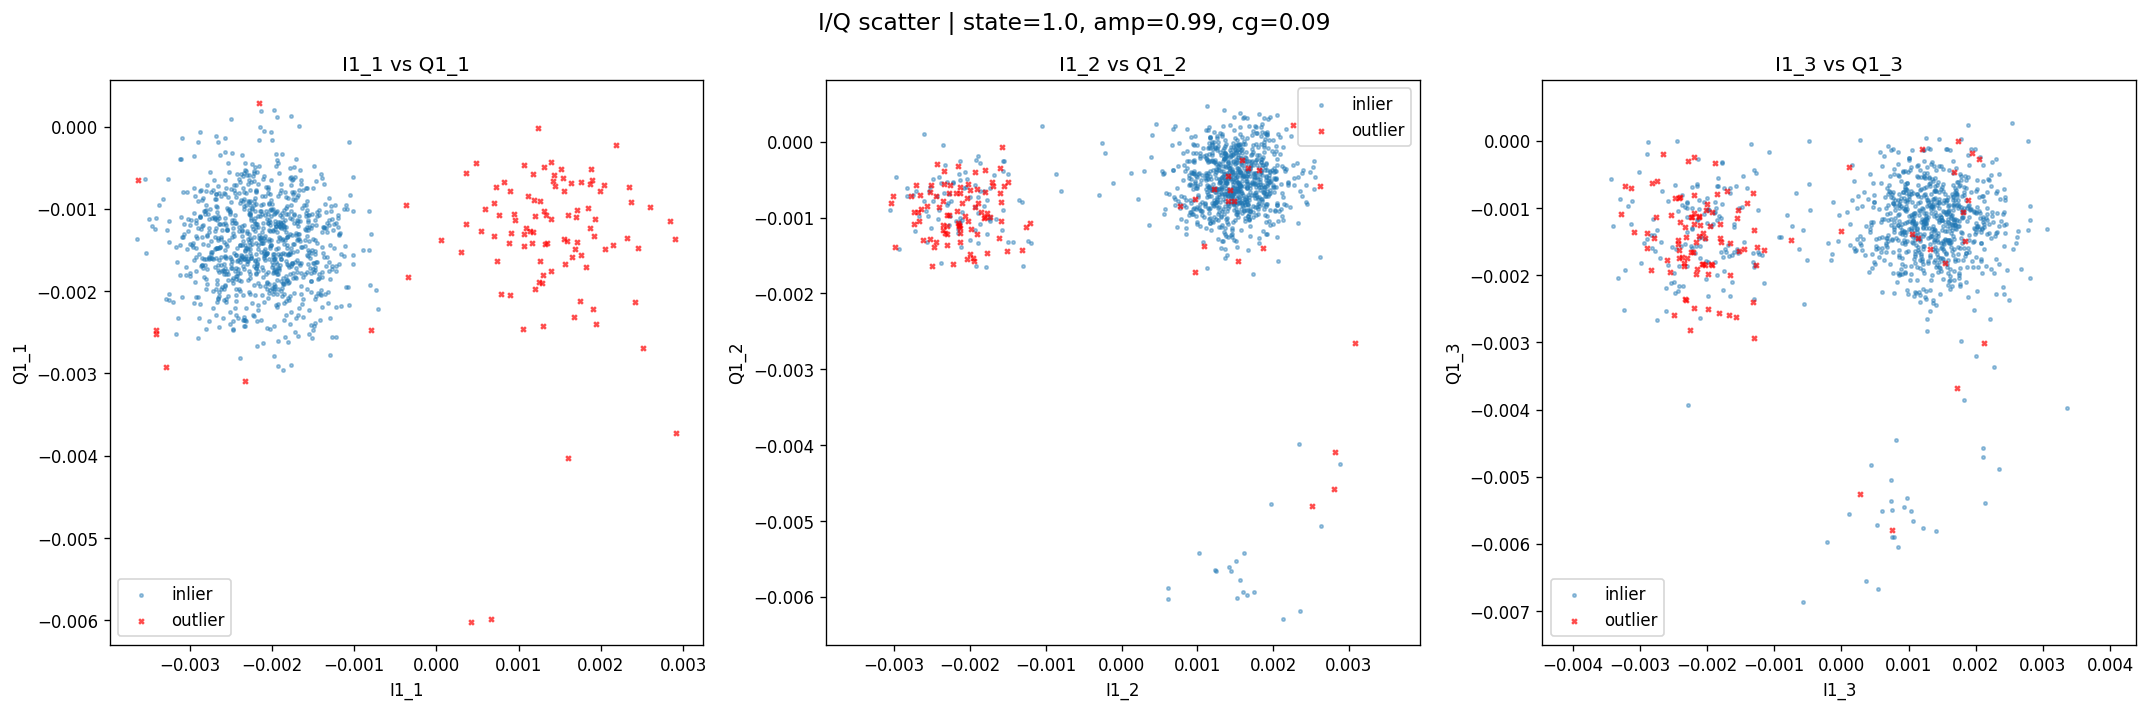

In [23]:
channel_pairs = [('I1_1', 'Q1_1'), ('I1_2', 'Q1_2'), ('I1_3', 'Q1_3')]
mask = cell['outlier_mask'].values.astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)
for ax, (i_var, q_var) in zip(axes, channel_pairs):
    I_vals = cell[i_var].values
    Q_vals = cell[q_var].values

    ax.scatter(I_vals[~mask], Q_vals[~mask], s=4, alpha=0.4, label='inlier', color='C0')
    ax.scatter(I_vals[mask],  Q_vals[mask],  s=8, alpha=0.7, label='outlier', color='red', marker='x')
    ax.set_xlabel(i_var)
    ax.set_ylabel(q_var)
    ax.set_title(f"{i_var} vs {q_var}")
    ax.legend()
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(f"I/Q scatter | state={actual_state}, amp={actual_amp}, cg={actual_cg}", fontsize=14)
fig.tight_layout()

fname = f"scatter_IQ_state{int(actual_state)}_amp{actual_amp}_cg{actual_cg}.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved mean_outlier_prob_state_0.png


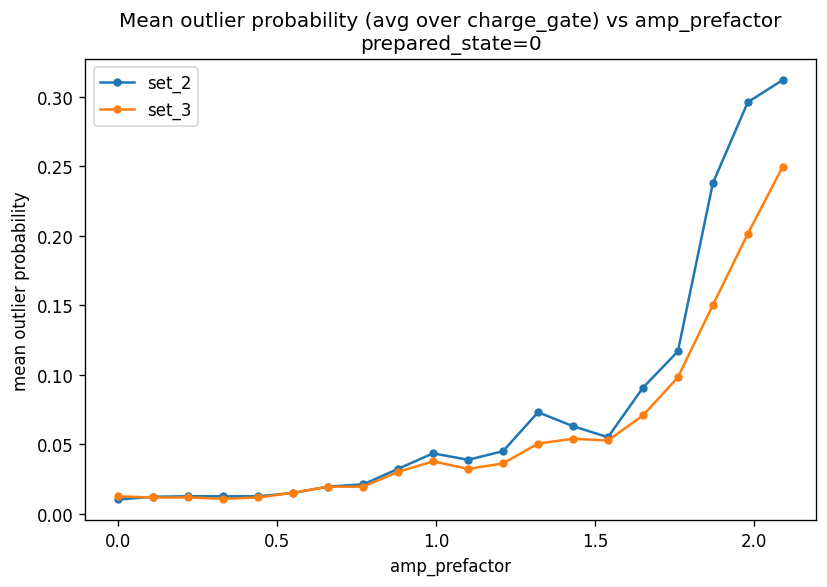

Saved mean_outlier_prob_state_1.png


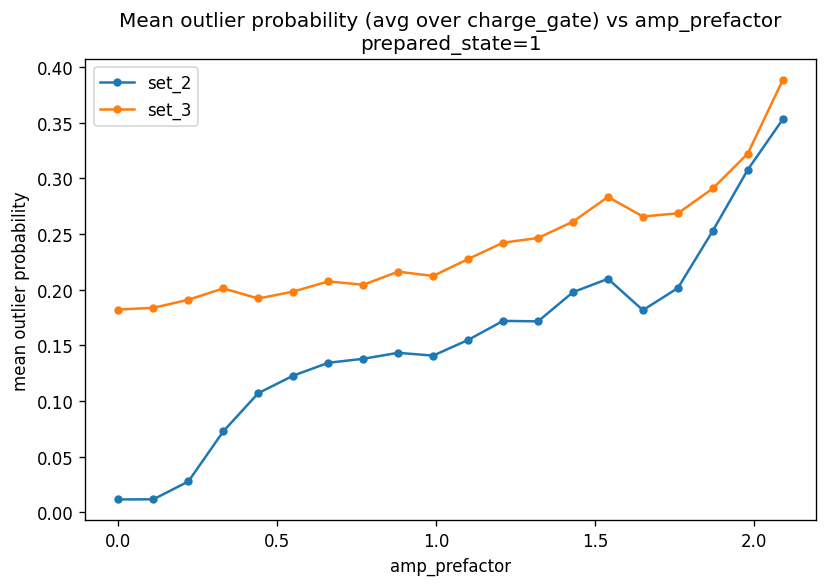

In [24]:
# Mean outlier probability averaged along charge_gate vs amp_prefactor
# set_2 and set_3 on the same figure, one figure per prepared_state

prepared_states = result_ds.coords['prepared_state'].values

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for var_name, set_label in [('outlier_probability_set2', 'set_2'),
                                 ('outlier_probability_set3', 'set_3')]:
        mean_outlier_vs_amp = result_ds[var_name].sel(prepared_state=state).mean(dim='charge_gate')
        mean_outlier_vs_amp.plot.line(ax=ax, marker='o', markersize=4, label=set_label)

    ax.set_xlabel('amp_prefactor')
    ax.set_ylabel('mean outlier probability')
    ax.set_title(f'Mean outlier probability (avg over charge_gate) vs amp_prefactor\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"mean_outlier_prob_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()